# Evaluación Global y Selección del Modelo Campeón

Este cuaderno pone fin a la fase de *Broad Sweep* (Barrido Algorítmico). Hemos evaluado cuatro arquitecturas matemáticas distintas (Naive Bayes, Regresión Logística, Random Forest y Boosting) bajo dos metodologías de tratamiento de datos (Desbalanceo original vs. Inyección SMOTE vs. Pesos de Clase).

Nuestro objetivo aquí es puramente analítico y visual. Vamos a extraer los registros del Tracker MLOps y generar tres gráficos corporativos que fundamenten matemáticamente la elección del modelo que pasará a producción:

1.  **Gráfico de Inteligencia General (F1-Macro):** Demuestra la capacidad del modelo para ser preciso en todas las colas de soporte sin sobreajustarse.
2.  **Gráfico de Impacto de Negocio (F1 de Averías Críticas):** Demuestra la capacidad específica para aislar el problema más grave de la empresa (Service Outages).
3.  **Gráfico de Coste Computacional (Tiempo de Entrenamiento):** La prueba MLOps del Retorno de Inversión (ROI). Demuestra por qué descartamos modelos que rinden bien pero colapsan la infraestructura.

### Paso 1: Inicialización del Entorno Visual y Fusión de Trackers
Cargamos las librerías gráficas, aseguramos la persistencia de las imágenes en la carpeta `images` (con sobreescritura automática) y unimos los historiales de inglés y español en un único *DataFrame* maestro para poder graficarlos en paralelo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- INICIALIZANDO ENTORNO VISUAL MLOPS ---")

# 1. GESTIÓN DE CARPETAS (Modo Idempotente)
# Creamos la carpeta 'images' en la raíz. Si existe, no hace nada.
# plt.savefig() se encargará luego de sobreescribir los archivos físicos.
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)
print(f"✅ Directorio de salida garantizado: {output_dir}")

# 2. CARGA DE TRACKERS HISTÓRICOS
df_en = pd.read_csv("../data/processed/tracker_en.csv")
df_es = pd.read_csv("../data/processed/tracker_es.csv")

# 3. FUSIÓN MAESTRA (Inglés y Español en la misma tabla)
df_en['Idioma'] = 'Inglés'
df_es['Idioma'] = 'Español'
df_master = pd.concat([df_en, df_es], ignore_index=True)

# 4. LIMPIEZA DE ETIQUETAS PARA LOS GRÁFICOS
# Juntamos el nombre del algoritmo y el tipo de balanceo para que el gráfico sea legible
# Ejemplo: "random_forest (smote)"
df_master['Configuracion'] = df_master['model'].str.upper() + " (" + df_master['balancing'].str.upper() + ")"

# 5. CONFIGURACIÓN VISUAL CORPORATIVA
# Aplicamos un tema profesional (fondo blanco con cuadrícula)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7) # Tamaño estándar de los lienzos

print("✅ Trackers fusionados. Listo para renderizar.")
display(df_master[['Idioma', 'Configuracion', 'f1_macro', 'train_time_sec']].tail(4))

--- INICIALIZANDO ENTORNO VISUAL MLOPS ---
✅ Directorio de salida garantizado: ../images
✅ Trackers fusionados. Listo para renderizar.


,Idioma,Configuracion,f1_macro,train_time_sec
14,Español,XGBOOST (WEIGHTS),0.5030,95.1703
15,Español,XGBOOST (SMOTE),0.4941,234.1503
16,Español,LIGHTGBM (WEIGHTS),0.5248,36.1125
17,Español,LIGHTGBM (SMOTE),0.5434,101.6787


### Paso 2: Inteligencia General (F1-Macro Global)

El F1-Macro es la métrica más exigente de nuestro proyecto. Al hacer una media no ponderada, castiga severamente a los modelos que aciertan en las colas mayoritarias (Technical Support) pero fallan estrepitosamente en las minoritarias (Sales o Outages). 

Este gráfico de barras horizontales nos permitirá visualizar el "techo de cristal" de los algoritmos lineales (LogReg) y cómo las técnicas de ensamblado superan esa barrera.

--- RENDERIZANDO: INTELIGENCIA GLOBAL (F1-MACRO) ---
✅ Gráfico guardado exitosamente en: ../images/01_F1_Macro_Global.png


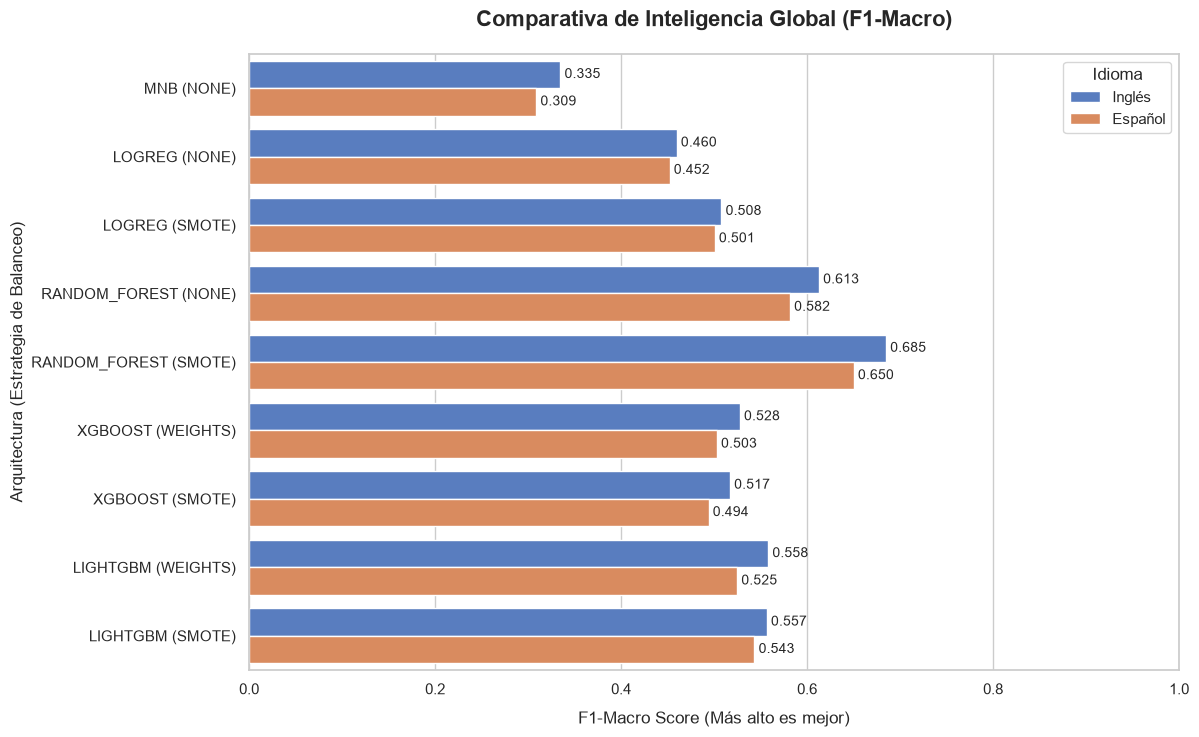

In [2]:
print("--- RENDERIZANDO: INTELIGENCIA GLOBAL (F1-MACRO) ---")

# 1. CREACIÓN DEL LIENZO
plt.figure(figsize=(12, 8))

# 2. RENDERIZADO DEL GRÁFICO DE BARRAS (Seaborn)
# Ponemos 'Configuracion' en la 'y' para que los nombres largos se lean de izquierda a derecha.
# hue='Idioma' nos crea automáticamente dos barras de colores por cada algoritmo.
barplot = sns.barplot(
    data=df_master, 
    x='f1_macro', 
    y='Configuracion', 
    hue='Idioma',
    palette='muted'
)

# 3. ESTÉTICA CORPORATIVA
plt.title('Comparativa de Inteligencia Global (F1-Macro)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('F1-Macro Score (Más alto es mejor)', fontsize=12, labelpad=10)
plt.ylabel('Arquitectura (Estrategia de Balanceo)', fontsize=12)
plt.xlim(0, 1.0) # Forzamos el eje X de 0 a 1 para no distorsionar la perspectiva

# 4. AÑADIR LOS VALORES EXACTOS EN LAS BARRAS
for container in barplot.containers:
    barplot.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

# 5. GUARDADO DESTRUCTIVO EN DISCO (Cumpliendo el requisito)
# bbox_inches='tight' asegura que no se corten los márgenes de la foto.
ruta_guardado_1 = "../images/01_F1_Macro_Global.png"
plt.savefig(ruta_guardado_1, bbox_inches='tight', dpi=300)
print(f"✅ Gráfico guardado exitosamente en: {ruta_guardado_1}")

# 6. MOSTRAR EN PANTALLA
plt.show()

### Paso 3: Impacto de Negocio (F1-Score de Averías Críticas)

Un algoritmo puede tener un F1-Macro decente engañando a las estadísticas (acertando masivamente en la clase fácil, *Technical Support*, y fallando en la clase difícil). 

Para garantizar el Retorno de Inversión (ROI) del proyecto, necesitamos aislar la métrica de la clase minoritaria: `Service Outages and Maintenance`. Este gráfico visualiza en exclusiva qué algoritmos son capaces de detectar apagones críticos de red sin generar falsas alarmas, demostrando el impacto real de inyectar datos sintéticos (SMOTE).

--- RENDERIZANDO: IMPACTO DE NEGOCIO (AVERÍAS CRÍTICAS) ---
✅ Gráfico de Negocio guardado exitosamente en: ../images/02_F1_Minority_Outages.png


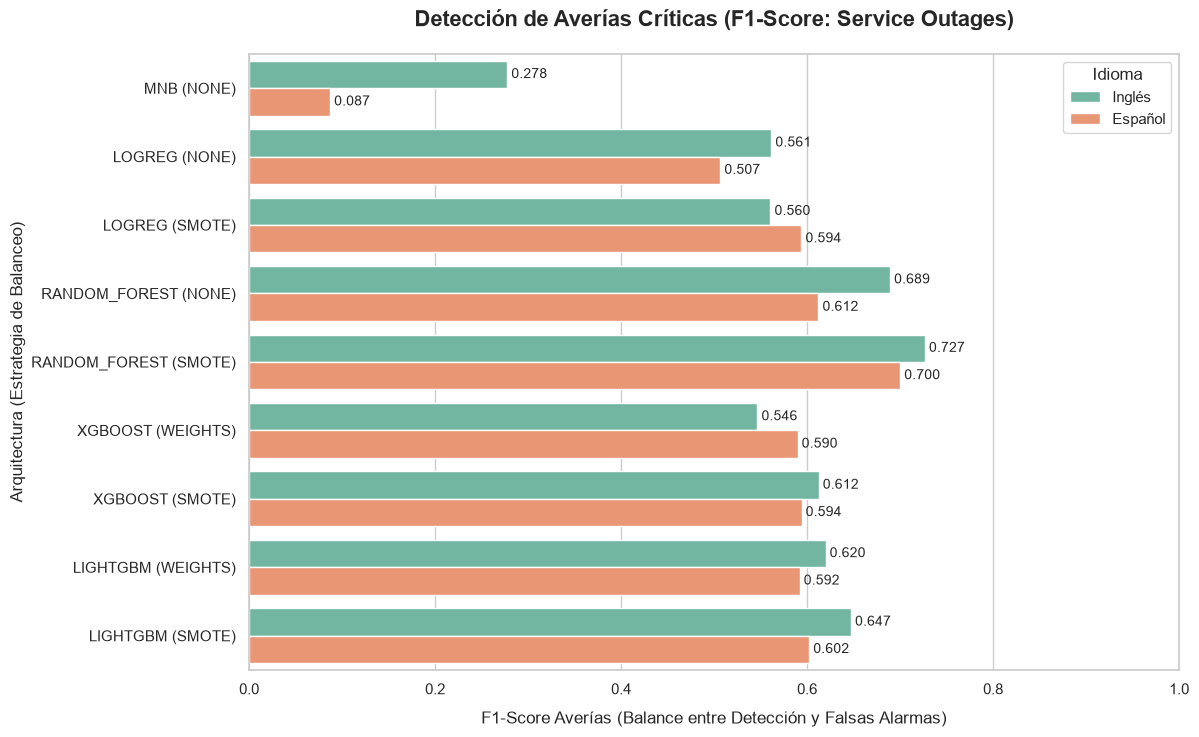

In [3]:
print("--- RENDERIZANDO: IMPACTO DE NEGOCIO (AVERÍAS CRÍTICAS) ---")

plt.figure(figsize=(12, 8))

# 1. RENDERIZADO DEL GRÁFICO (Eje X apuntando a la columna minoritaria)
barplot_min = sns.barplot(
    data=df_master, 
    x='f1_minority_class', 
    y='Configuracion', 
    hue='Idioma',
    palette='Set2' # Cambiamos la paleta de colores para diferenciarlo del anterior
)

# 2. ESTÉTICA CORPORATIVA
plt.title('Detección de Averías Críticas (F1-Score: Service Outages)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('F1-Score Averías (Balance entre Detección y Falsas Alarmas)', fontsize=12, labelpad=10)
plt.ylabel('Arquitectura (Estrategia de Balanceo)', fontsize=12)
plt.xlim(0, 1.0) # Honestidad visual: rango de 0 a 1

# 3. AÑADIR LOS VALORES
for container in barplot_min.containers:
    barplot_min.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

# 4. GUARDADO DESTRUCTIVO
ruta_guardado_2 = "../images/02_F1_Minority_Outages.png"
plt.savefig(ruta_guardado_2, bbox_inches='tight', dpi=300)
print(f"✅ Gráfico de Negocio guardado exitosamente en: {ruta_guardado_2}")

# 5. MOSTRAR
plt.show()

### Paso 4: Viabilidad MLOps (Coste de Infraestructura Computacional)

En entornos corporativos reales, la precisión de un modelo debe estar balanceada con el coste de entrenarlo y mantenerlo (Return on Investment - ROI). Los algoritmos de Gradient Boosting son célebres por su alta demanda de memoria y CPU. 

Este último gráfico expone de manera cruda el tiempo en segundos que cada algoritmo necesitó para procesar la matriz TF-IDF inyectada. Es la prueba pericial de por qué las arquitecturas secuenciales (*Boosting*) quedan descalificadas en este entorno frente a las arquitecturas de ensamblado paralelo (*Bagging* / Random Forest).

--- RENDERIZANDO: COSTE COMPUTACIONAL (TIEMPOS DE ENTRENAMIENTO) ---
✅ Gráfico MLOps guardado exitosamente en: ../images/03_Training_Time_ROI.png


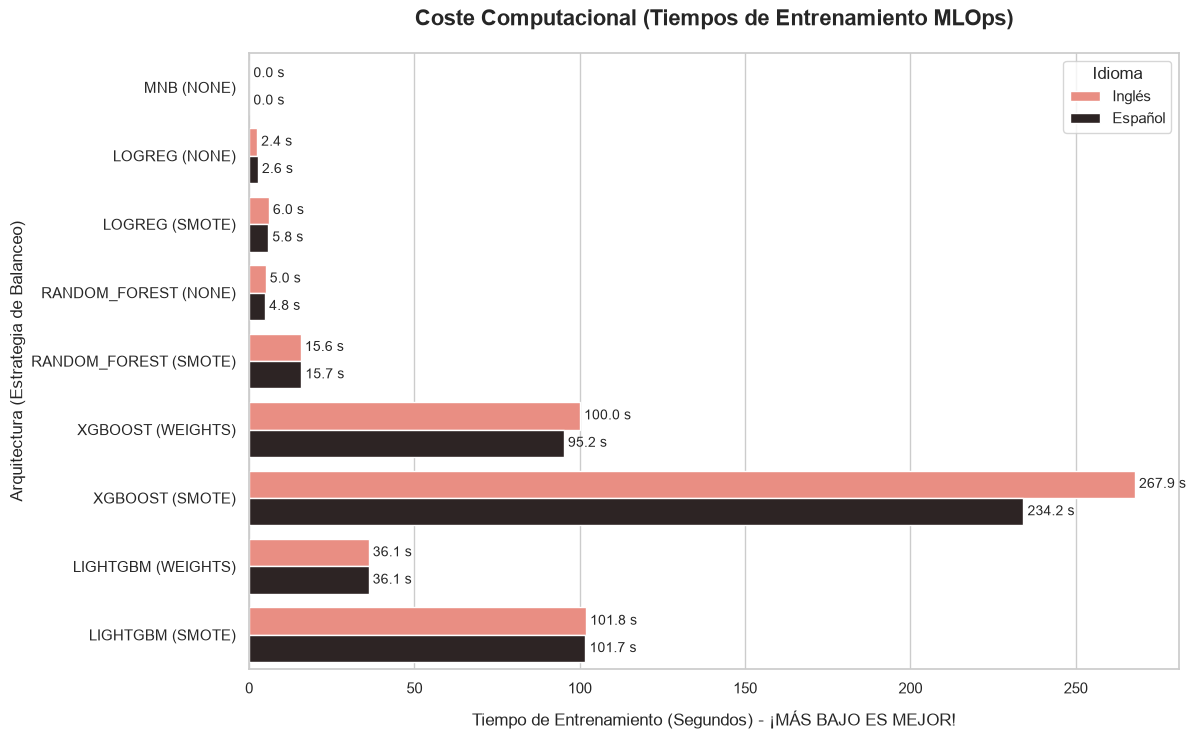

In [4]:
print("--- RENDERIZANDO: COSTE COMPUTACIONAL (TIEMPOS DE ENTRENAMIENTO) ---")

plt.figure(figsize=(12, 8))

# 1. RENDERIZADO DEL GRÁFICO (Eje X apuntando a los segundos de entrenamiento)
barplot_time = sns.barplot(
    data=df_master, 
    x='train_time_sec', 
    y='Configuracion', 
    hue='Idioma',
    palette='dark:salmon_r' # Paleta en tonos rojos para indicar "peligro/coste"
)

# 2. ESTÉTICA CORPORATIVA
plt.title('Coste Computacional (Tiempos de Entrenamiento MLOps)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tiempo de Entrenamiento (Segundos) - ¡MÁS BAJO ES MEJOR!', fontsize=12, labelpad=10)
plt.ylabel('Arquitectura (Estrategia de Balanceo)', fontsize=12)

# NOTA: Aquí NO forzamos el límite del eje X a 1.0, 
# porque el tiempo va desde milisegundos hasta casi 300 segundos.
# Dejamos que Matplotlib auto-ajuste la escala.

# 3. AÑADIR LOS VALORES (Redondeados a 1 decimal)
for container in barplot_time.containers:
    barplot_time.bar_label(container, fmt='%.1f s', padding=3, fontsize=10)

# 4. GUARDADO DESTRUCTIVO
ruta_guardado_3 = "../images/03_Training_Time_ROI.png"
plt.savefig(ruta_guardado_3, bbox_inches='tight', dpi=300)
print(f"✅ Gráfico MLOps guardado exitosamente en: {ruta_guardado_3}")

# 5. MOSTRAR
plt.show()

### Paso 5: Latencia en Producción (Tiempo de Inferencia API)

El coste de entrenamiento es un problema de infraestructura interna, pero el **Tiempo de Inferencia** (lo que tarda el modelo en predecir etiquetas sobre un conjunto de tickets nuevos) es un problema de experiencia de usuario y resiliencia de los servidores en tiempo real (API).

Este gráfico visualiza la latencia en milisegundos (`ms`). Nuestro objetivo es garantizar que el modelo ganador (Random Forest) es capaz de responder con una latencia inferior a 100ms, asegurando así un flujo asíncrono sin cuellos de botella cuando el modelo sea desplegado en producción.

--- RENDERIZANDO: LATENCIA DE INFERENCIA EN PRODUCCIÓN ---
✅ Gráfico de Latencia guardado exitosamente en: ../images/04_Inference_Latency_API.png


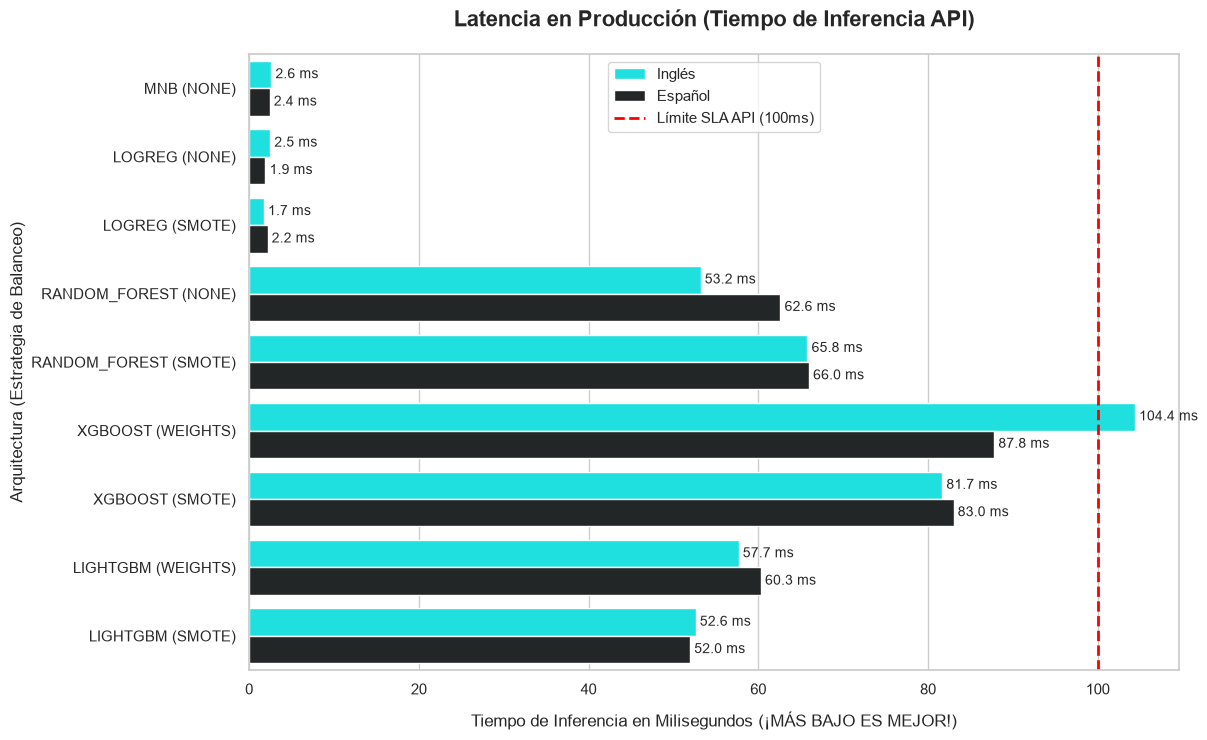

In [5]:
print("--- RENDERIZANDO: LATENCIA DE INFERENCIA EN PRODUCCIÓN ---")

plt.figure(figsize=(12, 8))

# 1. RENDERIZADO DEL GRÁFICO (Eje X apuntando a los milisegundos de inferencia)
barplot_inf = sns.barplot(
    data=df_master, 
    x='inference_time_ms', 
    y='Configuracion', 
    hue='Idioma',
    palette='dark:cyan_r' # Tonos cian/teal para métricas de velocidad API
)

# 2. ESTÉTICA CORPORATIVA
plt.title('Latencia en Producción (Tiempo de Inferencia API)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tiempo de Inferencia en Milisegundos (¡MÁS BAJO ES MEJOR!)', fontsize=12, labelpad=10)
plt.ylabel('Arquitectura (Estrategia de Balanceo)', fontsize=12)

# Añadimos una línea vertical roja marcando el límite de 100ms (SLA de negocio)
plt.axvline(x=100, color='red', linestyle='--', label='Límite SLA API (100ms)', linewidth=2)
plt.legend()

# 3. AÑADIR LOS VALORES (Redondeados a 1 decimal)
for container in barplot_inf.containers:
    barplot_inf.bar_label(container, fmt='%.1f ms', padding=3, fontsize=10)

# 4. GUARDADO DESTRUCTIVO
ruta_guardado_4 = "../images/04_Inference_Latency_API.png"
plt.savefig(ruta_guardado_4, bbox_inches='tight', dpi=300)
print(f"✅ Gráfico de Latencia guardado exitosamente en: {ruta_guardado_4}")

# 5. MOSTRAR
plt.show()